In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from coleta import customers, order_reviews, orders

- Primeira pergunta de negócio: Qual é o tempo médio entre a realização do pedido e a entrega?

In [3]:
tempo_medio_entrega = orders[orders['order_status'] == 'delivered'].copy()

In [4]:
tempo_medio_entrega = tempo_medio_entrega.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'])

In [5]:
tempo_medio_entrega['diferenca_entrega_compra_dias'] = (tempo_medio_entrega['order_delivered_customer_date'] - tempo_medio_entrega['order_purchase_timestamp']).dt.days

In [6]:
tempo_medio_entrega.groupby('diferenca_entrega_compra_dias').agg(frequencia=('diferenca_entrega_compra_dias', 'count')).sort_values(by='frequencia', ascending=False)

,frequencia
diferenca_entrega_compra_dias,
7,7651
6,6805
8,6745
9,6039
5,5810
...,...
188,1
191,1
195,1


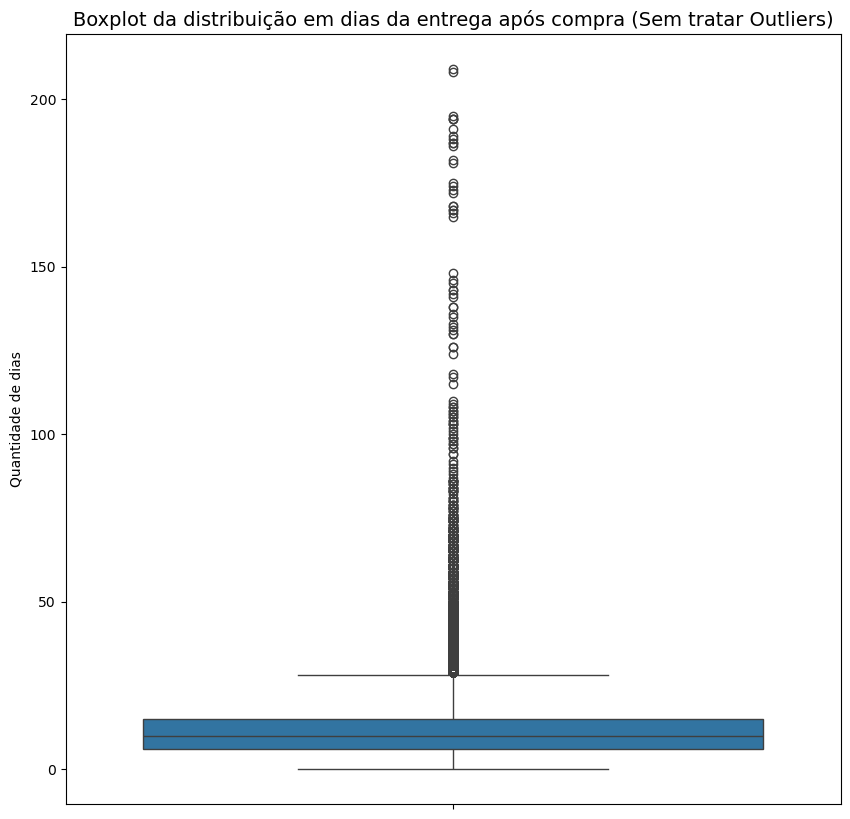

In [7]:
plt.figure(figsize=(10, 10))
sns.boxplot(y='diferenca_entrega_compra_dias', data=tempo_medio_entrega)
plt.title('Boxplot da distribuição em dias da entrega após compra (Sem tratar Outliers)', fontsize=14)
plt.ylabel('Quantidade de dias')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [8]:
# Removendo valores outliers do dataset

limite_supeior = tempo_medio_entrega['diferenca_entrega_compra_dias'].mean() + 3 * tempo_medio_entrega['diferenca_entrega_compra_dias'].std()

tempo_medio_entrega = tempo_medio_entrega[tempo_medio_entrega['diferenca_entrega_compra_dias'] < (limite_supeior)]

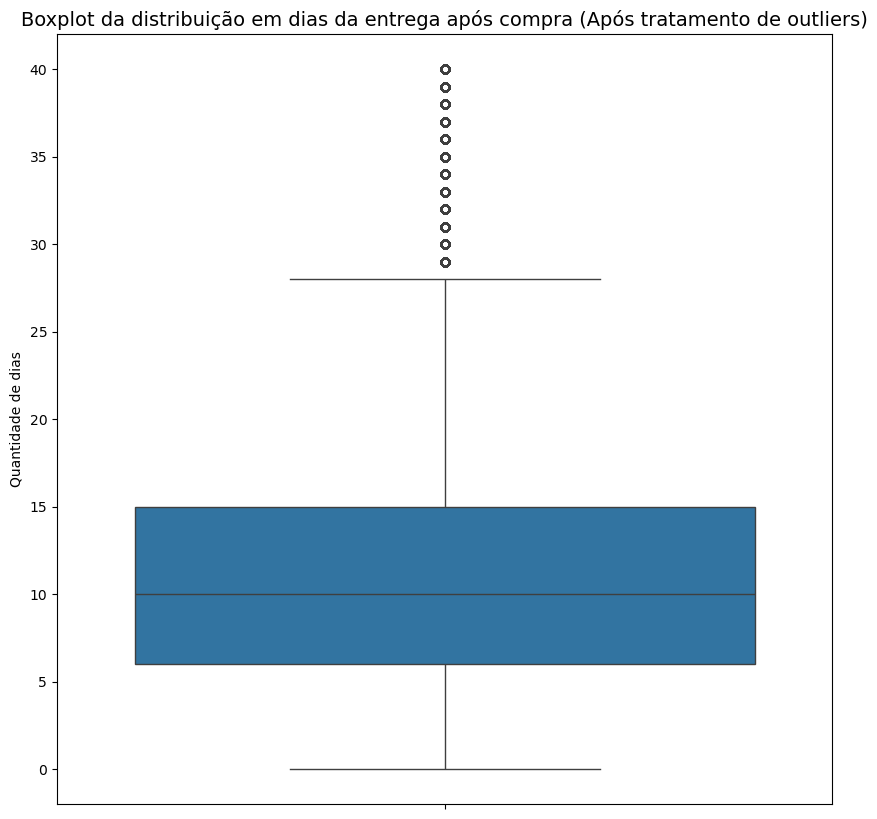

In [9]:
plt.figure(figsize=(10, 10))
sns.boxplot(y='diferenca_entrega_compra_dias', data=tempo_medio_entrega)
plt.title('Boxplot da distribuição em dias da entrega após compra (Após tratamento de outliers)', fontsize=14)
plt.ylabel('Quantidade de dias')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

    O tempo médio entre realização do pedido e a entrega é de 10 dias

- Segunda pergunta de negócio: Qual percentual dos pedidos foi entregue depois da data prevista?

In [10]:
entregas_atrasadas = orders[orders['order_estimated_delivery_date'] < orders['order_delivered_customer_date']].dropna(subset='order_delivered_customer_date')

In [11]:
quantidade_entregas_atrasadas = len(entregas_atrasadas)

In [12]:
quantidade_total_de_pedidos_entregues = len(orders.dropna(subset='order_delivered_customer_date'))

In [13]:
percentual_entregas_atrasadas = (quantidade_entregas_atrasadas / quantidade_total_de_pedidos_entregues) * 100

In [14]:
percentual_entregas_atrasadas

8.112898544715783

    O percentual de entregas feitas após a data prevista foi de 8.11%

- Terceira pergunta de negócio: Quais regiões apresentam maior ocorrência de atrasos?

In [15]:
regioes_entregas_atrasadas = entregas_atrasadas.merge(customers, on='customer_id').groupby('customer_state').agg(total_ocorrencias=('customer_id', 'count')).sort_values(by='total_ocorrencias', ascending=False).reset_index()

In [16]:
regioes_entregas_atrasadas

,customer_state,total_ocorrencias
0,SP,2387
1,RJ,1664
2,MG,638
3,BA,457
4,RS,382
5,SC,346
6,PR,246
7,ES,244
8,CE,196
9,PE,172


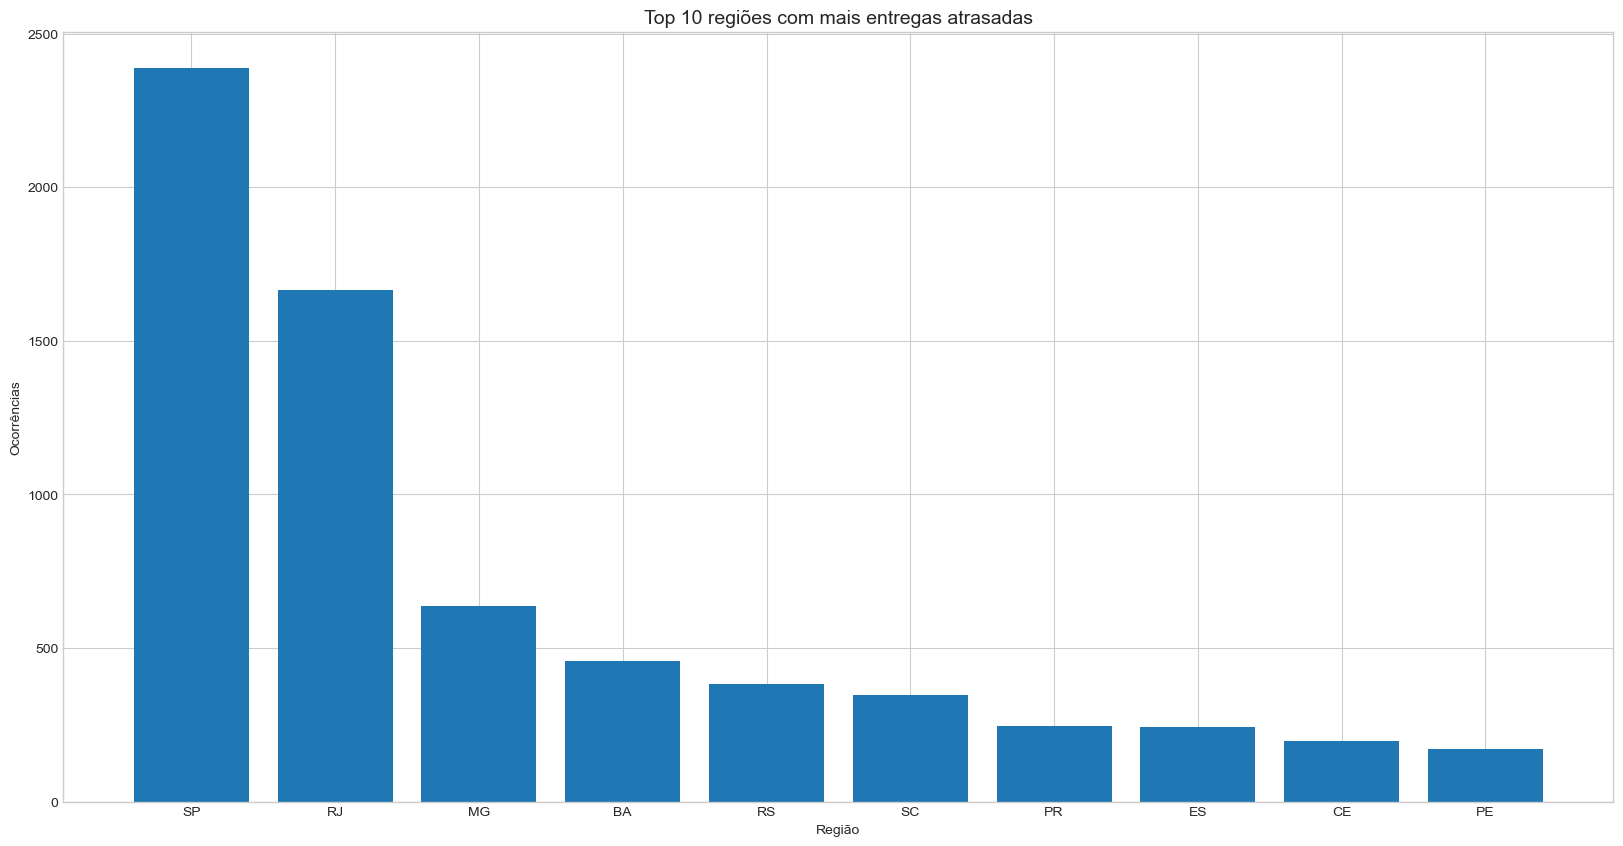

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(20, 10))
plt.bar(regioes_entregas_atrasadas['customer_state'].head(10), regioes_entregas_atrasadas['total_ocorrencias'].head(10))
plt.xlabel('Região')
plt.ylabel('Ocorrências')
plt.title('Top 10 regiões com mais entregas atrasadas', fontsize=14)
plt.show()

- Quarta pergunta de negócio: Existe relação entre atraso na entrega e avaliação do cliente?

In [18]:
atraso_entrega_review = orders.merge(order_reviews, on='order_id')

In [19]:
atraso_entrega_review = atraso_entrega_review.dropna(subset=['order_delivered_customer_date', 'order_purchase_timestamp', 'order_estimated_delivery_date'])

In [20]:
atraso_entrega_review['atrasou'] = np.where(atraso_entrega_review['order_delivered_customer_date'] > atraso_entrega_review['order_estimated_delivery_date'], 1, 0)

In [21]:
atraso_entrega_review = atraso_entrega_review[['review_score', 'atrasou']]

In [22]:
atraso_entrega_review

,review_score,atrasou
0,4,0
1,4,0
2,5,0
3,5,0
4,5,0
...,...,...
99219,5,0
99220,4,0
99221,5,0
99222,2,0


In [23]:
analise_de_correlacao = atraso_entrega_review.corr(method='pearson')
analise_de_correlacao

,review_score,atrasou
review_score,1.00000,-0.36442
atrasou,-0.36442,1.00000


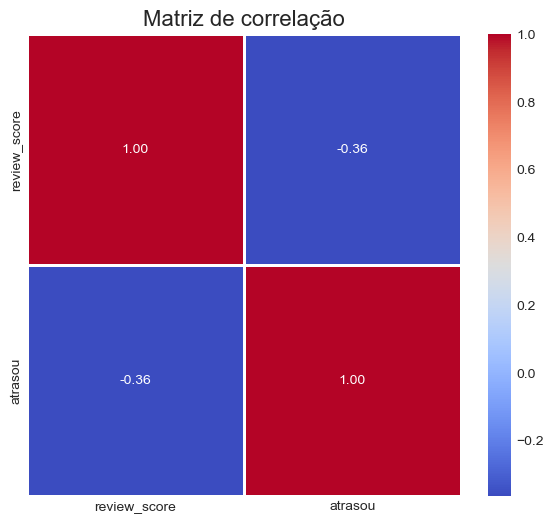

In [24]:
plt.figure(figsize=(7, 6))
sns.heatmap(analise_de_correlacao, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Matriz de correlação', fontsize=16)
plt.show()

        Sim, após uma análise de correlação de Pearson foi possível encontrar uma certa relação entre avaliação do cliente e atraso na entrega.

- Quinta pergunta de negócio: Clientes que tiveram problemas na entrega tendem a avaliar pior a experiência?

    Sim. A análise de correlação de Pearson mostrou um coeficiente de aproximadamente -0,36 entre atrasos na entrega e avaliações dos clientes. Isso indica uma relação negativa: pedidos atrasados tendem a estar associados a avaliações menores.